In [1]:
!which python
%load_ext autoreload
%autoreload 2

/home/aaronfurtado/Coding/BE PROJECT/Final/PANI-Precipitaiton-Analysis-for-Natural-Integration/env/bin/python


In [9]:
#If there are issues with importing modules. This is for reloading a module
import importlib
import computations_funcs
import plot_funcs
import data_collection
import pred_funcs
modules=[computations_funcs,plot_funcs,data_collection,pred_funcs]
for module in modules:
    importlib.reload(module)

In [10]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import os
import ee
from pred_funcs import get_pred_data,predict_image
from computations_funcs import resize_img
load_dotenv()

PROJECT_NAME = os.getenv("PROJECT_NAME")


In [5]:
mlp=joblib.load('mlp_model.joblib')
scaler=joblib.load('mlp_scaler.joblib')
print('Initializing Earth Engine')
try:
    ee.Initialize(project=PROJECT_NAME)
    print(f'Successfully initialized Earth Engine Project {PROJECT_NAME}')
except Exception as e:
    print('Initializing Earth Engine for the first time')
    ee.Authenticate()
    ee.Initialize(project=PROJECT_NAME)
    print(f'Successfully initialized Earth Engine Project {PROJECT_NAME}')

Initializing Earth Engine
Successfully initialized Earth Engine Project be-project-aaronfurtado2003


In [6]:
data,region_mask=get_pred_data()


List of Districts in West Bengal are:
['Dakshin Dinajpur', 'Uttar Dinajpur', 'West Midnapore', 'Bankura', 'Barddhaman', 'Birbhum', 'Darjiling', 'Haora', 'Hugli', 'Jalpaiguri', 'Kochbihar', 'Maldah', 'Murshidabad', 'Nadia', 'Puruliya', 'Kolkata', 'North 24 Parganas', 'South 24 Parganas', 'East Midnapore']


Selected Districts are:
['Puruliya']


/home/aaronfurtado/Coding/BE PROJECT/Final/PANI-Precipitaiton-Analysis-for-Natural-Integration/env/lib/python3.13/site-packages/ee/deprecation.py:207: DeprecationWarning: 

Attention required for COPERNICUS/S2_SR! You are using a deprecated asset.
To make sure your code keeps working, please update it.
Learn more: https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S2_SR

  warnings.warn(warning, category=DeprecationWarning)
/home/aaronfurtado/Coding/BE PROJECT/Final/PANI-Precipitaiton-Analysis-for-Natural-Integration/env/lib/python3.13/site-packages/ee/deprecation.py:207: DeprecationWarning: 

Attention required for COPERNICUS/S2! You are using a deprecated asset.
To make sure your code keeps working, please update it.
Learn more: https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S2

  warnings.warn(warning, category=DeprecationWarning)
/home/aaronfurtado/Coding/BE PROJECT/Final/PANI-Precipitaiton-Analysis-for-Natural-Integration/env/lib/python3

[INFO] Band 'dem' replacing 2245 NaNs with 86.53557653943346
[INFO] Band 'dist_to_water' replacing 2245 NaNs with 0.0
[INFO] Band 'flow_acc' replacing 2245 NaNs with 85.20621484552771
[INFO] Band 'ndwi' replacing 2245 NaNs with -0.4541675143648392
[INFO] Band 'rain' replacing 2245 NaNs with 4.93483543395996
[INFO] Band 'runoff_coeff' replacing 2245 NaNs with 4.2
[INFO] Band 'slope' replacing 2245 NaNs with 0.0
[INFO] Band 'soil_moisture' replacing 2245 NaNs with 12.399305343627926


In [7]:
updated_data={}
for band in data.keys():
    if band not in ['dem']:
        updated_data[band]=np.nan_to_num(data[band])

In [13]:
prediction=predict_image(updated_data,resize_img(region_mask),mlp,scaler)

/home/aaronfurtado/Coding/BE PROJECT/Final/PANI-Precipitaiton-Analysis-for-Natural-Integration/env/lib64/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


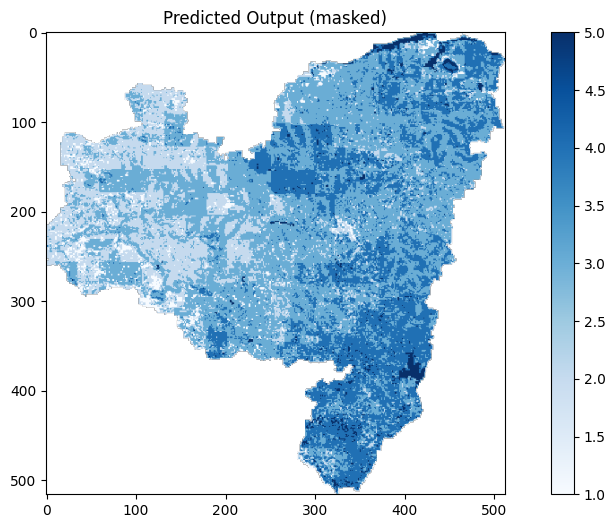

In [17]:
masked_pred = np.where(resize_img(region_mask) == 1, prediction, np.nan)
plt.figure(figsize=(12,6))
plt.imshow(masked_pred,cmap='Blues')
plt.title("Predicted Output (masked)")
plt.colorbar()
plt.show()